# Spatial variability from forest structure characteristics

High-resolution forest structure products provide a promising new EO data stream for constraining spatial variability across flux-tower sites. Using the harmonised extraction pipeline, we derived site-level metrics of canopy height, above-ground biomass, and tree cover, together with two Chapman–Richards parameters describing (i) maximum annual carbon accumulation rate and (ii) asymptotic maximum above-ground carbon stock. These metrics were compared to site-aggregated NEE residuals from FLUXCOM‑X, defined here as the difference between observed and predicted long-term mean annual NEE, i.e. the unexplained *spatial* component of model error. The initial analysis used 16 test sites distributed globally and spanning multiple plant functional types.

______

While the data extraction scripts shown in this repository show an overview of the extraction pipeline for one site, the extended analysis requires all 16 sites to be fully downloaded. The helper script `download_ForestStructure` ensures all data is downloaded. The helper script is entirely based on the demonstraction script in `data_extraction/data_extraction.ipynb`.

**Note:** the script takes about an hour to run, depending on connection speeds. The script will skip any downloads which are already complete.

In [1]:
from download_ForestStructure import get_download

In [2]:
msds = get_download()

/home/data/home/Packages/eo-lincs-scs1/.pixi/envs/default/lib/python3.13/site-packages/pystac_client/client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())


Using the same `MultiSourceDataStore` allows for an overview map of the sites in this analysis.

In [3]:
msds.display_geolocations()

In [4]:
import os
import xarray as xr
import matplotlib.pyplot as pl
import numpy as np
from scipy.stats import linregress
import forest_structure_utils as uf

First, we'll load a single site with all forest structure characteristics to show the variability. As some products have a temporal dimension, while others do not, we will select the year 2020 for an initial analysis.

In [5]:
site = "FR-Fon"
forest_products = [
    "CCI_BIOMASS",
    "HANSEN_GFC",
    "POTAPOV_HEIGHT",
    "ROBINSON_CR",
    "SAATCHI_BIOMASS"
]

def get_site_data(site, forest_products=forest_products):
    datasets = []
    for product in forest_products:
        datasets.append( xr.open_zarr(f"../data/{site}/{product}.zarr", consolidated=False) )
        datasets[-1] = datasets[-1].rename(
            {vname:f"{product.split('_')[0]}_{vname}" for vname in datasets[-1].data_vars}
        )
    datasets.append( uf.s2_dist_from_tower_calc(site) )
    return xr.merge(datasets, join="outer", compat="no_conflicts").assign_coords(site=site)

ds = get_site_data(site).sel(time="2020")
ds

<xarray.Dataset> Size: 23MB
Dimensions:                                    (time: 1, x: 400, y: 400)
Coordinates:
  * time                                       (time) datetime64[ns] 8B 2020-...
  * x                                          (x) float64 3kB 4.818e+05 ... ...
  * y                                          (y) float64 3kB 5.371e+06 ... ...
    spatial_ref                                int64 8B 0
    site                                       <U6 24B 'FR-Fon'
Data variables: (12/18)
    CCI_aboveground_biomass                    (time, y, x) float64 1MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    CCI_aboveground_biomass_std                (time, y, x) float64 1MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    HANSEN_data_mask                           (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    HANSEN_gain                                (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    HANSEN_loss_year                           (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    HANSEN_tree_cover                          (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ...                                         ...
    ROBINSON_cr_k                              (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ROBINSON_cr_k_error                        (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ROBINSON_max_rate                          (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ROBINSON_max_removal_potential_benefit_25  (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    SAATCHI_agb                                (y, x) float64 1MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    dist_from_tower                            (y, x) float64 1MB 2.823e+03 ....
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        CCI_BIOMASS_v6.0
    xcube_stac_version:  1.3.1

Forested sites often have taller towers and therefore larger and more variable flux footprints, so a simple 1 km radius average may not match the true sampling area. Footprint climatologies are not routinely available across networks, limiting direct footprint-aware aggregation. ICOS Class 1 sites, however, publish regions of interest, and the figure below illustrates how these can differ from a generic 1 km circle. Extending this comparison across ICOS sites will help quantify the error introduced by the fixed-radius approach. More broadly, emerging footprint estimation tools should allow future workflows to aggregate high-resolution EO cut-outs using site-specific footprint information.

Text(0.5, 1.05, 'Above Ground Biomass')

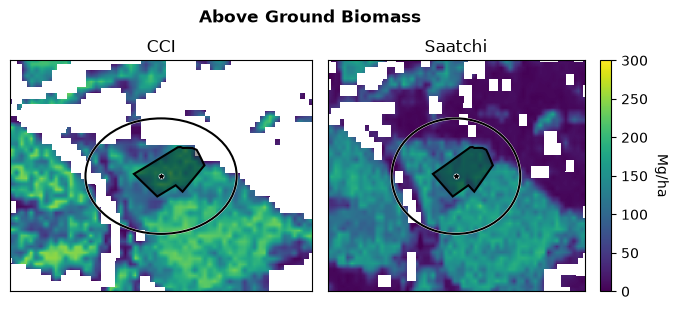

In [6]:
fig, axs = pl.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True)

img = ds["SAATCHI_agb"].plot(ax=axs[1], vmin=0, vmax=300, add_colorbar=False)
axs[1].set_title("Saatchi")

ds["CCI_aboveground_biomass"].plot(ax=axs[0], vmin=0, vmax=300, add_colorbar=False)
axs[0].set_title("CCI")

fig.subplots_adjust(wspace=0.05)
cbax = fig.colorbar(img, ax=axs[1], orientation='vertical', fraction=.1)
cbax.set_label(ds["CCI_aboveground_biomass"].units, rotation=-90, labelpad=15)

for ax in axs:
    uf.add_tower(ax, site, "Black")
    ax.set_xlabel(None)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

fig.suptitle("Above Ground Biomass", y=1.05, fontweight="bold")

The ICOS-defined region of interest for the Fontainebleau–Barbeau site (FR‑Fon) is shown alongside two above-ground biomass maps. Areas of low biomass to the north correspond to agricultural fields, while the low-biomass band to the east aligns with a river corridor.


However, as we do not have a defined region of interest for each tower, this example will take the averate over a 1 km radius for all sites.

Here we load the residual data for all the sites, which has been pre-caluculated using the FLUXCOM-X cross validation data. Here resiudals were calculated as the difference of longterm mean net ecosystem exchange (NEE) between the cross validation prediction and the observations:

$$
NEE_{resid} = \overline{NEE_{pred}} - \overline{NEE_{obs}}
$$

The residual values are in $g C \cdot m^{-2} \cdot yr^{-1}$.

In [7]:
from forest_structure_utils import residual_data

all_sites = residual_data.keys()#sorted(os.listdir("../data/"))

for site, resid in residual_data.items():
    print(site, "->", resid)

BE-Lon -> 0.5491401727023678
CD-Ygb -> 0.8752077855450568
CH-Dav -> -0.8820181453259748
CZ-Lnz -> 0.5030513239372677
DE-Hai -> 0.3973944780093158
DE-RuR -> -0.8943771827841218
DE-Tha -> 1.4044495174852416
ES-LMa -> -0.11640112911489914
GF-Guy -> -0.23782457785660738
IT-Noe -> -0.8351959411192529
US-Rpf -> -0.008840619293998467
US-SRG -> -0.8512773522604116
US-UMB -> -0.10998935199889504
US-UMd -> 0.6264346734917793
US-Var -> -0.34932102276217075
US-xDS -> 1.5773855721468055


Now, we build a dataset with the mean values of all forest structure characteristics, taken as the spatial mean within a 1 km radius of the tower, and pair with the corresponding NEE residual.

In [8]:
site_data = {site:get_site_data(site).sel(time="2020") for site in all_sites}

forest_ds = xr.concat(
    [site_data[site].where(site_data[site].dist_from_tower>1000).mean() for site in all_sites],
    "site"
)
forest_ds["NEE_resid"] = (("site",), [residual_data[site] for site in all_sites])

Similarly, we add metrics from GEDI lidar shots around the tower. Here we use the mean estimated above ground biomass and 95th percentile of relative height.

In [9]:
gedi_ds = []
for site in all_sites:
    try:
        gedi = xr.open_zarr(f"../data/{site}/gedi.zarr/")
        gedi["dist_from_tower"] = uf.gedi_dist_from_tower_calc(gedi, site)
        gedi = gedi.where(uf.gedi_qc_mask(gedi))
        _agb = gedi.where(gedi.dist_from_tower<1000).agbd.mean().rename("GEDI_agbd")
        _rh_95 = gedi.where(gedi.dist_from_tower<1000).rh.sel(profile_points=95).mean().rename("GEDI_rh_95")
        gedi_ds.append( xr.merge([_agb, _rh_95], compat="no_conflicts", join = "outer").assign_coords(site=site) )
    except FileNotFoundError:
        gedi_ds.append( (gedi_ds[0]*np.nan).assign_coords(site=site).compute() )
forest_ds = forest_ds.merge(xr.concat(gedi_ds, "site"), compat='no_conflicts')

In [10]:
forest_ds

<xarray.Dataset> Size: 3kB
Dimensions:                                    (site: 16)
Coordinates:
  * site                                       (site) <U6 384B 'BE-Lon' ... '...
    spatial_ref                                int64 8B 0
    profile_points                             int16 2B 95
Data variables: (12/21)
    CCI_aboveground_biomass                    (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    CCI_aboveground_biomass_std                (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    HANSEN_data_mask                           (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    HANSEN_gain                                (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    HANSEN_loss_year                           (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    HANSEN_tree_cover                          (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                         ...
    ROBINSON_max_removal_potential_benefit_25  (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    SAATCHI_agb                                (site) float64 128B dask.array<chunksize=(1,), meta=np.ndarray>
    dist_from_tower                            (site) float64 128B 1.741e+03 ...
    NEE_resid                                  (site) float64 128B 0.5491 ......
    GEDI_agbd                                  (site) float32 64B dask.array<chunksize=(1,), meta=np.ndarray>
    GEDI_rh_95                                 (site) float32 64B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        CCI_BIOMASS_v6.0
    xcube_stac_version:  1.3.1

As shown in the figure below, all forest structure metrics exhibit a positive relationship with the NEE residuals, although correlations are generally weak. The common positive trend suggests that larger forest biomass or cover may be associated with systematic spatial errors in NEE. However, the sample size is still small and may be influenced by confounding effects—most notably that more productive ecosystems tend to have both larger flux magnitudes and higher biomass. In addition, several sites in the test set are not forested, which reduces the interpretability of forest-specific metrics; future analyses should restrict the comparison to appropriate subsets (e.g., forest PFTs) and expand the site sample.

In [11]:
forest_products = [
    'CCI_aboveground_biomass',
    'HANSEN_tree_cover',
    'POTAPOV_canopy_height',
    'ROBINSON_cr_a',
    'ROBINSON_max_rate',
    'SAATCHI_agb',
    'GEDI_agbd',
    'GEDI_rh_95'
]

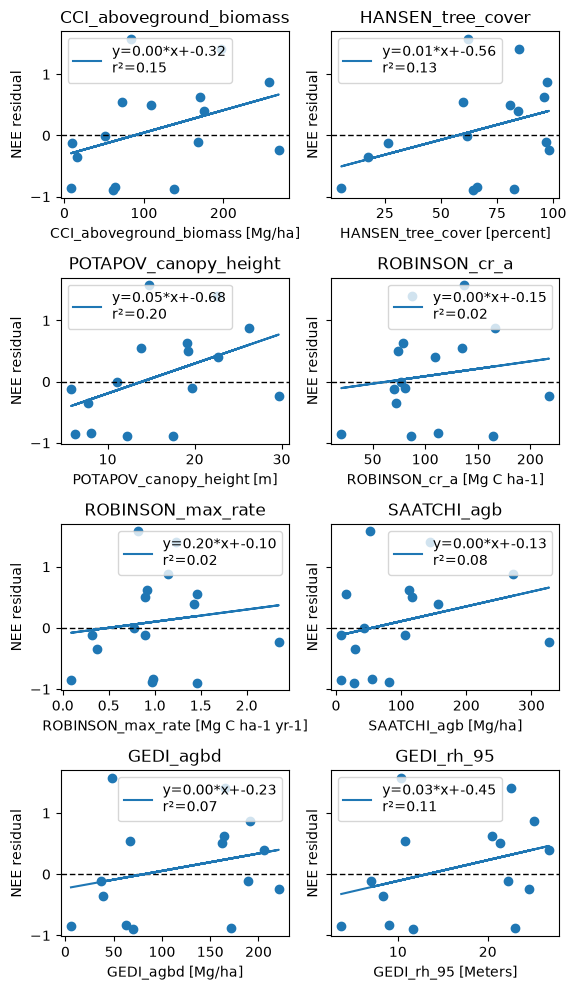

In [12]:
fig, axs = pl.subplots(4, 2, figsize=(6,10), sharey=True)

i = 0
for product in forest_products:
    x = forest_ds[product].values
    y = forest_ds.NEE_resid.values

    lrg = linregress(x, y, nan_policy="omit")
    ax = axs.ravel()[i]
    ax.scatter(
        x,
        y
    )
    
    xlim = np.linspace(x.min(), x.max())
    ax.axhline(0, dashes=(4,2), lw=1, color="k")
    ax.plot(x, x*lrg.slope+lrg.intercept, label=f"y={lrg.slope:.2f}*x+{lrg.intercept:.2f}\nr²={lrg.rvalue**2:.2f}")
    ax.legend()
    ax.set_xlabel(f"{product} [{forest_ds[product].attrs['units']}]")
    ax.set_ylabel("NEE residual")
    ax.set_title(f"{product}")
    i+=1

fig.tight_layout()